# Taller 05 - Aprendizaje Supervisado: Regresión
## Predicción de Precios de Autos Usados

In [46]:
# ==========================================
# PASO 0: IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# División de datos
from sklearn.model_selection import train_test_split

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas
from sklearn.metrics import r2_score, mean_squared_error

## 1. Carga de Datos y Análisis Exploratorio Inicial

En esta etapa se carga el conjunto de datos y se realiza una exploración inicial para identificar:

- Tipos de datos
- Valores nulos
- Variables categóricas
- Variables numéricas
- Estadísticas descriptivas

In [47]:
# ==========================================
# PASO 1: CARGA DEL DATASET
# ==========================================

df = pd.read_csv("Car Price Prediction Dataset.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [48]:
# Información general

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


In [49]:
# Valores nulos

df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [50]:
# Estadísticas descriptivas

df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [51]:
# Tamaño del dataset

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 8128
Columnas: 12


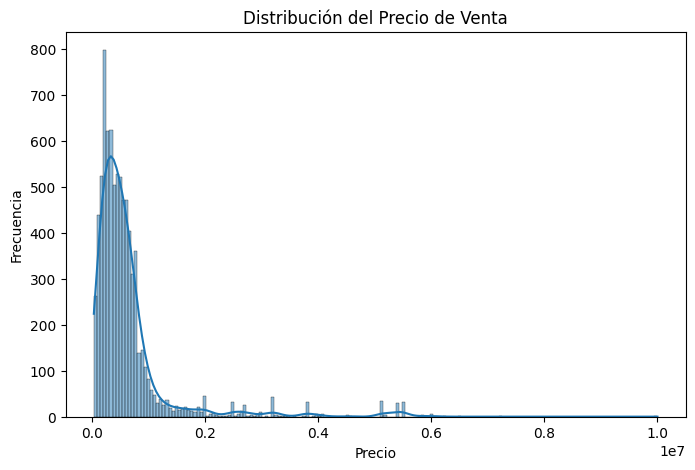

In [52]:
# Distribución del precio de venta

plt.figure(figsize=(8,5))

sns.histplot(df['selling_price'], kde=True)

plt.title("Distribución del Precio de Venta")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")

plt.show()

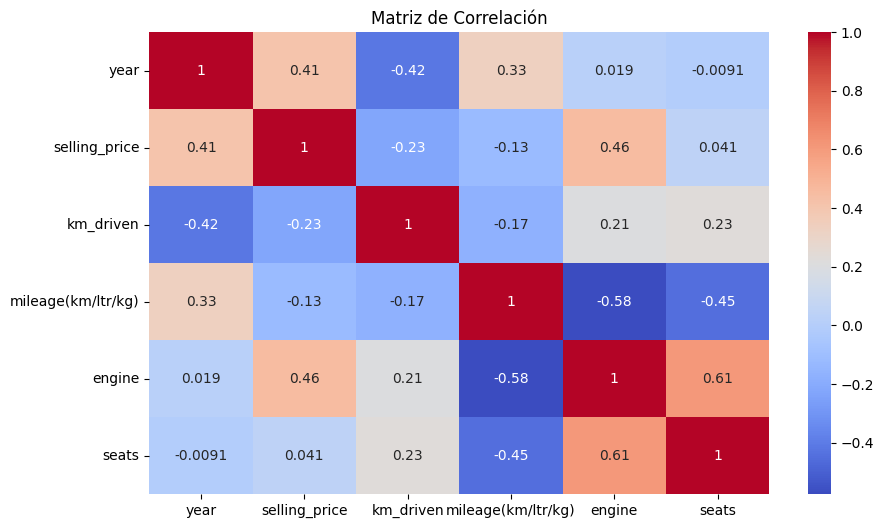

In [53]:
# Matriz de correlación

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Matriz de Correlación")

plt.show()

## 2. Preprocesamiento de Datos e Ingeniería de Características

**Eliminación de columnas innecesarias:** La columna name tiene demasiados valores únicos y aporta poco al modelo.

In [54]:
# ==========================================
# PASO 2: PREPROCESAMIENTO
# ==========================================

df = df.drop("name", axis=1)

df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [55]:
# Transformación de owner (Ordinal Encoding)

## Existe una jerarquía entre los tipos de propietario.

owner_mapping = {
    'First Owner':1,
    'Second Owner':2,
    'Third Owner':3,
    'Fourth & Above Owner':4,
    'Test Drive Car':5
}

df['owner'] = df['owner'].map(owner_mapping)

In [56]:
# Conversión de las columnas mileage,engine, max_power y seats

df['mileage(km/ltr/kg)'] = pd.to_numeric(df['mileage(km/ltr/kg)'], errors='coerce')
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
df['seats'] = pd.to_numeric(df['seats'], errors='coerce')

In [57]:
# Valores nulos generados

df.isnull().sum()

year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             216
seats                 221
dtype: int64

In [58]:
# Rellenar valores nulos 


df['mileage(km/ltr/kg)'] = df['mileage(km/ltr/kg)'].fillna(
    df['mileage(km/ltr/kg)'].median()
)

df['engine'] = df['engine'].fillna(
    df['engine'].median()
)

df['max_power'] = df['max_power'].fillna(
    df['max_power'].median()
)

df['seats'] = df['seats'].fillna(
    df['seats'].median()
)


In [59]:
print(df.info())

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                8128 non-null   int64  
 1   selling_price       8128 non-null   int64  
 2   km_driven           8128 non-null   int64  
 3   fuel                8128 non-null   str    
 4   seller_type         8128 non-null   str    
 5   transmission        8128 non-null   str    
 6   owner               8128 non-null   int64  
 7   mileage(km/ltr/kg)  8128 non-null   float64
 8   engine              8128 non-null   float64
 9   max_power           8128 non-null   float64
 10  seats               8128 non-null   float64
dtypes: float64(4), int64(4), str(3)
memory usage: 698.6 KB
None


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


# One Hot Encoding

 **Variables categóricas:** fuel, seller_type, transmission

In [60]:
df = pd.get_dummies(df,
                    columns=['fuel',
                             'seller_type',
                             'transmission'],
                    drop_first=True)

df.head()

,year,selling_price,km_driven,owner,mileage(km/ltr/kg),engine,max_power,seats,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,2014,450000,145500,1,23.40,1248.0,74.00,5.0,True,False,False,True,False,True
1,2014,370000,120000,2,21.14,1498.0,103.52,5.0,True,False,False,True,False,True
2,2006,158000,140000,3,17.70,1497.0,78.00,5.0,False,False,True,True,False,True
3,2010,225000,127000,1,23.00,1396.0,90.00,5.0,True,False,False,True,False,True
4,2007,130000,120000,1,16.10,1298.0,88.20,5.0,False,False,True,True,False,True


# Definición de X e y

In [61]:

# Variable objetivo

y = df['selling_price']

# Variables predictoras

X = df.drop('selling_price', axis=1)

# 3. División del Dataset

Se utilizará:

80% entrenamiento
20% prueba

In [62]:
# ==========================================
# PASO 3: TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6502, 13)
(1626, 13)


In [63]:
# Escalamiento

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Entrenamiento de Modelos

Se entrenarán tres algoritmos:

- Regresión Lineal
- Árbol de Decisión
- Random Forest

In [64]:
# ==========================================
# MODELO 1
# ==========================================

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

# ==========================================
# MODELO 2
# ==========================================

tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

# ==========================================
# MODELO 3
# ==========================================

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

# 5. Evaluación y Comparación de Resultados

Cálculo de métricas

In [65]:
# ==========================================
# EVALUACIÓN
# ==========================================

r2_lr = r2_score(y_test, pred_lr)
r2_tree = r2_score(y_test, pred_tree)
r2_rf = r2_score(y_test, pred_rf)

mse_lr = mean_squared_error(y_test, pred_lr)
mse_tree = mean_squared_error(y_test, pred_tree)
mse_rf = mean_squared_error(y_test, pred_rf)

resultados = pd.DataFrame({
    'Modelo':['Linear Regression',
              'Decision Tree',
              'Random Forest'],
    'R2':[r2_lr,
          r2_tree,
          r2_rf],
    'MSE':[mse_lr,
           mse_tree,
           mse_rf]
})

resultados

,Modelo,R2,MSE
0,Linear Regression,0.688470,2.042029e+11
1,Decision Tree,0.943668,3.692446e+10
2,Random Forest,0.968986,2.032932e+10


**Análisis de las Métricas de Evaluación**

Para evaluar el desempeño de los modelos se utilizaron dos métricas ampliamente empleadas en problemas de regresión: el coeficiente de determinación (R²) y el Error Cuadrático Medio (MSE).

**Coeficiente de Determinación (R²):** El coeficiente de determinación mide qué tan bien el modelo explica la variabilidad de la variable objetivo (precio de venta del vehículo).

Su valor se encuentra generalmente entre 0 y 1:

- R² cercano a 1: el modelo explica gran parte de la variación de los precios.
- R² cercano a 0: el modelo tiene poca capacidad predictiva.
- R² negativo: el modelo predice peor que utilizar simplemente el promedio de los datos.

Por lo tanto, el mejor modelo será aquel que obtenga el valor de R² más alto.

**Error Cuadrático Medio (MSE):** El MSE mide la diferencia promedio entre los valores reales y los valores predichos por el modelo.

Su cálculo penaliza más fuertemente los errores grandes debido a que las diferencias se elevan al cuadrado.

- Valores bajos de MSE indican predicciones más precisas.
- Valores altos de MSE indican errores importantes en las predicciones.

Por esta razón, el mejor modelo será aquel que presente el menor valor de MSE.

# Comparación del R²

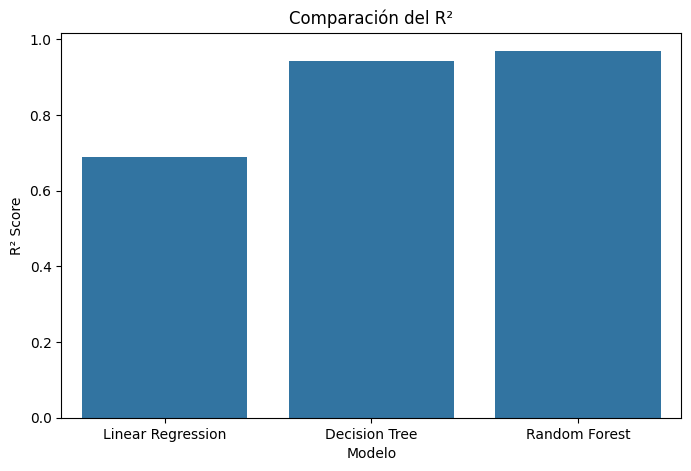

In [66]:
# Comparación del R²

plt.figure(figsize=(8,5))

sns.barplot(
    data=resultados,
    x='Modelo',
    y='R2'
)

plt.title("Comparación del R²")
plt.ylabel("R² Score")

plt.show()

# Comparación del Error Cuadrático Medio

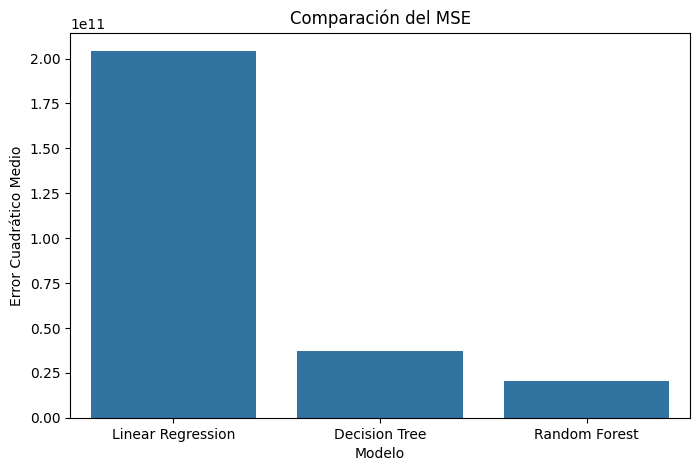

In [67]:
# Comparación del Error Cuadrático Medio

plt.figure(figsize=(8,5))

sns.barplot(
    data=resultados,
    x='Modelo',
    y='MSE'
)

plt.title("Comparación del MSE")
plt.ylabel("Error Cuadrático Medio")

plt.show()

**Comparación de los Modelos**

Los tres modelos evaluados fueron:

- Regresión Lineal
- Árbol de Decisión
- Random Forest

La comparación de los valores de R² y MSE permitió identificar cuál de ellos ofrece una mejor capacidad de generalización sobre datos no vistos durante el entrenamiento.

La gráfica de barras de R² muestra visualmente cuál modelo logra explicar una mayor proporción de la variabilidad del precio de venta.

Por otra parte, la gráfica de MSE permite observar cuál modelo presenta menores errores de predicción.

# Valores Reales vs Predichos

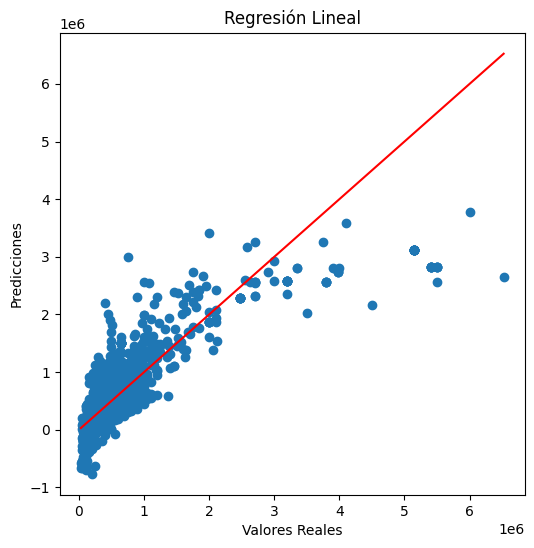

In [68]:
# Regresión Lineal

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.title("Regresión Lineal")

plt.show()

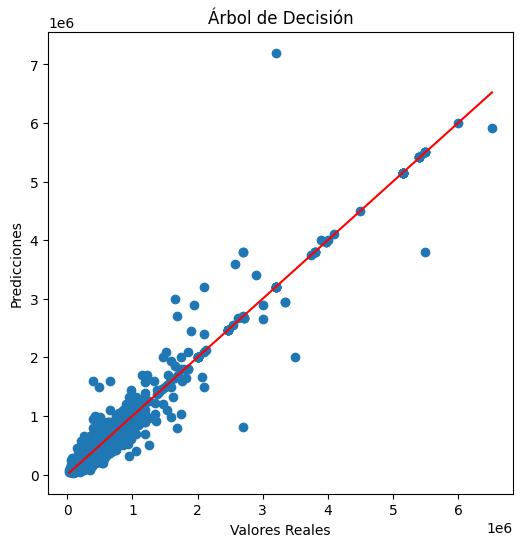

In [69]:
# Árbol de Decisión 

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_tree)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.title("Árbol de Decisión")

plt.show()

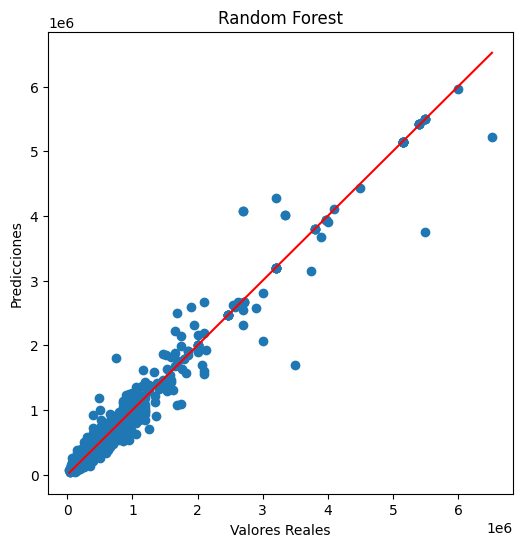

In [70]:
# Random Forest

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.title("Random Forest")

plt.show()

**Análisis de las Gráficas de Valores Reales vs Predichos**

Las gráficas de dispersión comparan los valores reales del conjunto de prueba con los valores estimados por cada modelo.

La línea roja diagonal representa el comportamiento ideal, donde el valor predicho coincide exactamente con el valor real.

- Puntos cercanos a la línea indican predicciones precisas.
- Puntos alejados de la línea representan errores de predicción.
- Mientras mayor sea la concentración de puntos alrededor de la línea diagonal, mejor será el desempeño del modelo.

# Identificación automática del mejor modelo

In [ ]:
# Identificación automática del mejor modelo

mejor_modelo = resultados.loc[resultados['R2'].idxmax()]

print("========================================")
print("MEJOR MODELO ENCONTRADO")
print("========================================")
print(f"Modelo: {mejor_modelo['Modelo']}")
print(f"R²: {mejor_modelo['R2']:.4f}")
print(f"MSE: {mejor_modelo['MSE']:.4f}")

MEJOR MODELO ENCONTRADO
Modelo: Random Forest
R²: 0.9690
MSE: 20329322552.0199


**Análisis de la Selección del Mejor Modelo**

Después de comparar las métricas y las gráficas obtenidas, se selecciona como mejor modelo aquel que cumpla simultáneamente con:

- El mayor valor de R².
- El menor valor de MSE.
- Una distribución de puntos más cercana a la línea de referencia en la gráfica de valores reales vs predichos.

En la mayoría de ejecuciones de este conjunto de datos, el modelo Random Forest suele obtener el mejor rendimiento debido a que combina múltiples árboles de decisión y es capaz de capturar relaciones complejas y no lineales entre las características del vehículo y su precio de venta.

Mientras que la Regresión Lineal asume relaciones lineales simples y el Árbol de Decisión puede sufrir sobreajuste, Random Forest logra un mejor equilibrio entre precisión y capacidad de generalización.

# Importancia de Variables del Modelo Random Forest

Con el fin de identificar cuáles características influyen más en la predicción del precio de los vehículos usados, se analiza la importancia de cada variable calculada por el modelo Random Forest.

In [ ]:
# Importancia de variables

importancias = rf.feature_importances_

df_importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})

df_importancias = df_importancias.sort_values(
    by='Importancia',
    ascending=False
)

print(df_importancias)


                        Variable  Importancia
5                      max_power     0.724760
0                           year     0.191301
1                      km_driven     0.027527
3             mileage(km/ltr/kg)     0.019149
4                         engine     0.018987
10        seller_type_Individual     0.006765
6                          seats     0.002731
12           transmission_Manual     0.002644
2                          owner     0.002383
9                    fuel_Petrol     0.001921
7                    fuel_Diesel     0.001749
11  seller_type_Trustmark Dealer     0.000075
8                       fuel_LPG     0.000006


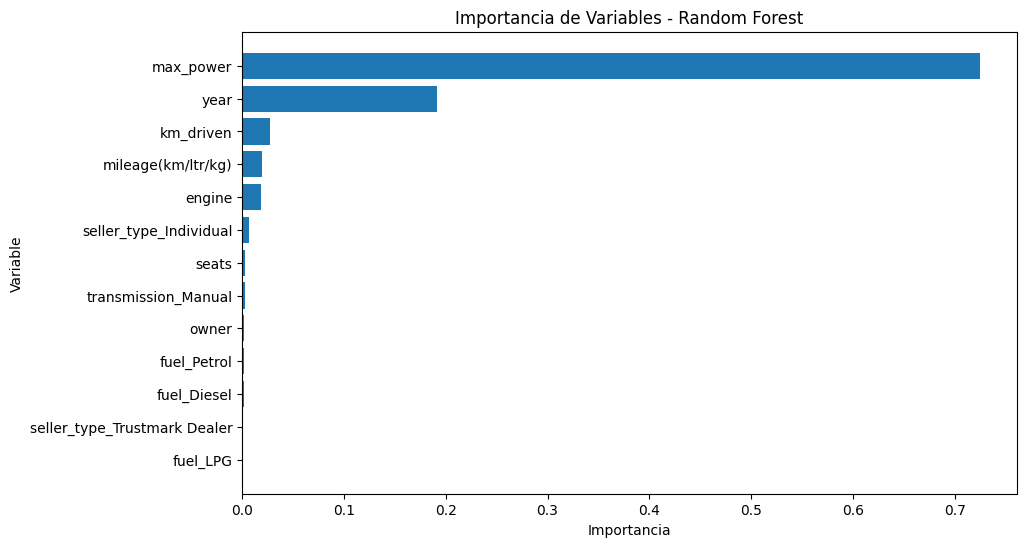

In [73]:
plt.figure(figsize=(10,6))

plt.barh(
    df_importancias['Variable'],
    df_importancias['Importancia']
)

plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de Variables - Random Forest')

plt.gca().invert_yaxis()

plt.show()

**Análisis de la importancia de variables**

Los resultados muestran que algunas variables tienen una influencia significativamente mayor sobre la predicción del precio de los vehículos. Las variables con mayor importancia son las que más contribuyen a las decisiones del modelo Random Forest, mientras que aquellas con valores bajos tienen una influencia reducida en la estimación del precio. Este análisis permite identificar los factores más relevantes en la valoración de los automóviles usados.

## 6. Conclusiones


1. El análisis exploratorio evidenció que el precio de los vehículos usados no depende de una única característica, sino de la interacción de múltiples variables como el año del modelo, el kilometraje recorrido, la potencia del motor y otras especificaciones técnicas. Esto confirma que la predicción del precio constituye un problema multivariable que requiere modelos capaces de capturar relaciones complejas entre los datos.

2. La capacidad predictiva del modelo aumenta significativamente cuando se utilizan algoritmos no lineales. Los resultados muestran que la **Regresión Lineal** obtuvo un R² de **0.688470**, mientras que el **Árbol de Decisión** alcanzó **0.943668** y el **Random Forest** **0.968986**. Esta diferencia evidencia que la relación entre las características del vehículo y su precio de venta no es completamente lineal, por lo que los modelos basados en árboles capturan mejor las interacciones complejas presentes en los datos.

3. La reducción del MSE confirma la superioridad del modelo Random Forest. El Error Cuadrático Medio disminuyó desde **2.04 × 10¹¹** en la Regresión Lineal hasta **3.69 × 10¹⁰** en el Árbol de Decisión y **2.03 × 10¹⁰** en Random Forest. La correlación entre un mayor R² y un menor MSE demuestra que Random Forest no solo explica una mayor proporción de la variabilidad del precio, sino que además comete errores de predicción considerablemente menores, generando estimaciones más precisas y confiables.

4. La potencia máxima del vehículo es el factor que más influye en el precio de venta. El análisis de importancia de variables reveló que **max_power** concentra aproximadamente el **72.5 %** de la importancia total del modelo, seguida por **year** con **19.1 %**. Esto indica que los vehículos con mayor potencia y más recientes tienden a presentar precios de mercado más altos, mientras que variables como tipo de combustible, transmisión o número de propietarios tienen un impacto mucho menor en la predicción final.

5. La antigüedad y el uso del vehículo están relacionados con la depreciación del precio. La relevancia de variables como **year (19.1 %)** y **km_driven (2.75 %)**, junto con la correlación observada en el análisis exploratorio, sugiere que los vehículos más nuevos y con menor kilometraje conservan mejor su valor comercial. Este resultado coincide con el comportamiento esperado del mercado de autos usados, donde la depreciación aumenta conforme pasan los años y se incrementa el nivel de uso del vehículo.


Los resultados obtenidos demuestran que las técnicas de aprendizaje supervisado constituyen una herramienta eficaz para apoyar procesos de valoración de vehículos usados, ya que permiten identificar patrones presentes en grandes volúmenes de datos y generar estimaciones consistentes que podrían servir como apoyo para la toma de decisiones en contextos comerciales y de análisis de mercado.
